In [ ]:
from src.graph.orchestrator_graph import HierarchicalAgent
from src.graph.orchestrator_graph.preprocessing import prepare_orchestrator_input
from src.database.data_preprocessor import preprocess_user
from IPython.display import Image, display

/Users/rogier/dev/joho/advies_agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.graph.orchastrator.retriever.graphs import retriever_subgraph

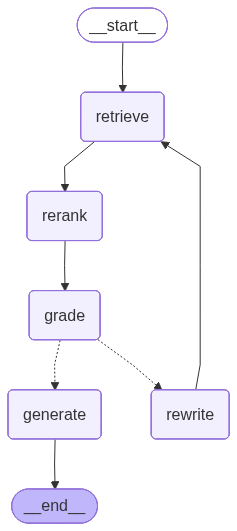

In [5]:
from src.agents.retriever import RetrieverAgent
retriever_agent = RetrieverAgent()
display(Image(retriever_agent.graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage
from src.graph.orchastrator.retriever import retriever_subgraph

result = retriever_subgraph.invoke({
    "messages": [HumanMessage(content="your query here")],
    "provider": "joho_werelddekking",
    "query": "medical emergency coverage",
    "aspect": "medical_coverage",
    "product_description": "...",
    "retrieval_summary": {},
})

print(result["retrieval_summary"])

In [2]:
# Preprocess a user by aanvraag_id
user = preprocess_user(92)
inputs = prepare_orchestrator_input(user)

print(f"Providers: {inputs['available_providers']}")
print(f"Product descriptions loaded: {list(inputs['product_descriptions'].keys())}")
print(f"User profile keys: {list(inputs['user_profile'].keys())}")

Providers: ['oom_wib', 'allianz_globetrotter', 'goudse_expat_pakket', 'oom_tib', 'goudse_ngo_zendelingen', 'special_isis', 'globality_yougenio', 'expatriate_group', 'International Expat Insurance', 'goudse_working_nomad']
Product descriptions loaded: ['oom_wib', 'allianz_globetrotter', 'goudse_expat_pakket', 'oom_tib', 'goudse_ngo_zendelingen', 'special_isis', 'globality_yougenio', 'expatriate_group', 'goudse_working_nomad']
User profile keys: ['aanvraag_id', 'family', 'deductible_requested', 'hoofdreden_verblijf', 'toelichting_hoofdreden', 'verwachte_duur_verblijf', 'toelichting_duur', 'interesse_internationale_aov', 'interesse_zkv', 'zkv_dekkingsvariant', 'zkv_eigen_risico_voorkeur', 'zkv_periode', 'huidige_verzekeraar', 'voorkeur_verzekeraar', 'medische_bijzonderheden', 'specifieke_wensen_zkv', 'dekking_zwangerschap', 'sporten_activiteiten', 'sport_semiprofessioneel', 'eerder_contact_joho', 'advies_vorm']


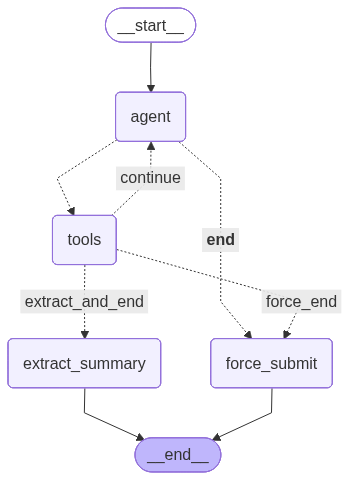

In [3]:
display(Image(retriever_subgraph.get_graph().draw_mermaid_png()))

In [2]:
agent = HierarchicalAgent()
thread_id = "my-run-3"

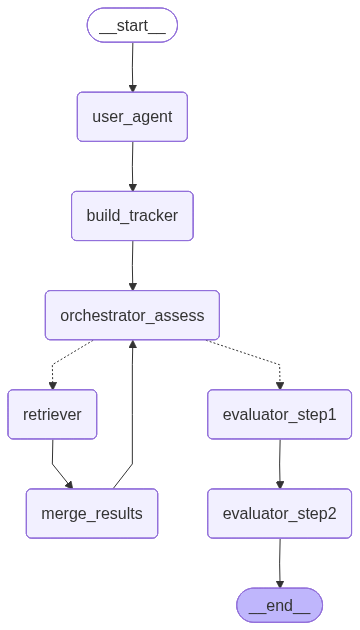

In [ ]:

display(Image(agent.graph.get_graph().draw_mermaid_png()))

In [4]:
# 1. Maak een variabele aan om de totale state in op te bouwen
final_result = {}
stream_error = None

# 2. Stream execution — see each node as it completes
try:
    for event in agent.stream(**inputs, thread_id=thread_id):
        node_name = list(event.keys())[0]
        updates = event[node_name]
        
        # 3. Voeg de data van deze node toe aan onze verzamel-variabele
        final_result.update(updates)

        print(f"\n{'='*60}")
        print(f"Node: {node_name}")
        print(f"Returned keys: {list(updates.keys())}")

        # Show key info per node
        if node_name == "user_agent":
            pc = updates.get("parsed_constraints", {})
            aspects = pc.get("retrieval_aspects", [])
            print(f"  Retrieval aspects: {[a['aspect'] for a in aspects]}")
            print(f"  Interpreted needs: {pc.get('interpreted_needs', [])}")

        elif node_name == "build_tracker":
            tracker = updates.get("retrieval_tracker", {})
            for p, data in tracker.items():
                levels = list(data.get("coverage_levels", {}).keys())
                print(f"  {p}: {len(data['aspects'])} aspects, levels={levels}")

        elif node_name == "orchestrator_assess":
            tasks = updates.get("retrieval_tasks", [])
            tracker = updates.get("retrieval_tracker", {})
            dropped = [p for p, d in tracker.items() if d.get("status") == "dropped"]
            print(f"  Tasks dispatched: {len(tasks)}")
            for t in tasks:
                print(f"    -> {t['provider']}: {t['aspect']} | {t['query'][:80]}")
            if dropped:
                print(f"  Dropped providers: {dropped}")

        elif node_name == "retriever":
            summaries = updates.get("retrieval_summaries", [])
            for s in summaries:
                if s:
                    print(f"  {s.get('provider')}/{s.get('aspect')}: confidence={s.get('confidence')}")
                    print(f"    {s.get('overall_summary', '')[:120]}...")

        elif node_name == "merge_results":
            print(f"  Iteration: {updates.get('retrieval_iteration')}")

        elif node_name == "evaluator_step1":
            qa = updates.get("qualitative_assessment", {})
            assessments = qa.get("assessments", [])
            for a in assessments:
                print(f"  {a['provider']} {a['coverage_level']}: €{a['premium']}")
                print(f"    Fit: {a['overall_fit'][:100]}...")

        elif node_name == "evaluator_step2":
            rec = updates.get("recommendation", {})
            print("  TOP RECOMMENDATIONS:")
            for r in rec.get("top_recommendations", []):
                print(f"    {r['provider']} {r['coverage_level']} (€{r['premium']})")
            print("  BUDGET RECOMMENDATIONS:")
            for r in rec.get("budget_recommendations", []):
                print(f"    {r['provider']} {r['coverage_level']} (€{r['premium']})")

except Exception as e:
    stream_error = e
    print(f"\n{'!'*60}")
    print(f"ERROR at node stream: {type(e).__name__}: {e}")
    print(f"Partial results saved in 'final_result' with keys: {list(final_result.keys())}")

# 4. Nadat de loop klaar is, heb je nu de complete state tot je beschikking!
print(f"\n{'*'*60}")
print("STREAM COMPLEET." if stream_error is None else "STREAM INCOMPLETE (partial results saved).")
print("Alle keys in 'final_result':", list(final_result.keys()))


Node: user_agent
Returned keys: ['parsed_constraints']
  Retrieval aspects: ['Eligibility and residency requirements for UAE residents', 'Geographical coverage: UAE as country of residence and temporary travel in Europe', 'Inpatient and outpatient benefits under a medium plan', 'Deductible application rules (per policy year / per claim / per condition) and currency handling', 'Emergency treatment, evacuation and repatriation benefits', 'Sports and hazardous activities coverage: surfing and gym', 'Pre-existing condition definition and underwriting/medical questionnaire rules', 'Maternity benefits exclusions, optional riders, and waiting periods', 'Policy term, renewability, premium review, and cancellation conditions for multi-year cover', 'Network providers in UAE and direct billing vs reimbursement', 'Coordination of benefits and overlap with existing insurance (current insurer Zorgzaam)']
  Interpreted needs: ['Internationale zorgverzekering (ZKV) met meerjarige looptijd, passend bi

In [9]:
final_result["parsed_constraints"] = final_result.get("parsed_constraints", {})
final_result["retrieval_tracker"] = final_result.get("retrieval_tracker", {})
final_result["retrieval_tasks"] = final_result.get("retrieval_tasks", [])
final_result["retrieval_summaries"] = final_result.get("retrieval_summaries", [])
final_result["qualitative_assessment"] = final_result.get("qualitative_assessment", {})
final_result["recommendation"] = final_result.get("recommendation", {})

In [6]:
final_result["recommendation"] 

{'top_recommendations': [{'provider': 'goudse_expat_pakket',
   'coverage_level': 'Optimaal',
   'premium': 2840.0,
   'reasoning': 'Dit is de beste ‘overall fit’ voor een 28-jarige zelfstandige expat die meerdere jaren in de UAE woont en tussendoor door Europa reist: het product is expliciet ontworpen voor expats incl. freelancers/zzp’ers, heeft een meerjarig karakter (min. 1 jaar) en combineert zorg + sterke SOS-assistance (evacuatie/repatriëring, search & rescue). Het eigen risico sluit exact aan op je wens (€500) en is bovendien per gezin/polis per polisjaar, wat bij twee personen in de praktijk vaak gunstiger uitpakt dan per persoon.',
   'trade_offs': 'Je accepteert een belangrijk onzeker punt rond surfen: ‘dangerous sports’ is breed en niet-limitatief (als het niet op de lijst staat, beslist de verzekeraar). Ook accepteer je administratieve frictie: bij >120 dagen aaneengesloten verblijf buiten het woonland op de polis moet je dit melden en kan de verzekeraar beperkingen oplegge

In [7]:
final_result["parsed_constraints"]

{'core': {'age': 28,
  'destination': 'Verenigde Arabische Emiraten (woonachtig) + reizend door Europa',
  'duration': '2 - 5 jaar (meerjarig verblijf/dekking gewenst)',
  'employment_type': 'Zelfstandig ondernemer (eigen onderneming)',
  'trip_type': 'Expat/Emigratie met doorlopend reizen (multi-country)'},
 'interpreted_needs': ['Internationale zorgverzekering (ZKV) met meerjarige looptijd, passend bij emigratie naar de UAE en regelmatig reizen binnen Europa (doorlopende dekking i.p.v. korte reisverzekering).',
  "Dekking voor geplande en spoedeisende zorg in zowel woonland (UAE) als tijdens tijdelijk verblijf/reizen in Europa; belangrijk om te checken hoe 'country of residence' en 'temporary travel' in de polis zijn gedefinieerd.",
  'Middenklasse/medium dekking: voldoende voor reguliere zorg en onverwachte kosten, maar waarschijnlijk met beperktere (luxere) opties; vooral relevant in de UAE waar private zorg duur kan zijn.',
  'Eigen risico/deductible van €500: behoefte aan lagere 

In [8]:
final_result["retrieval_tracker"]


{'oom_wib': {'status': 'active',
  'aspects': {'Eligibility and residency requirements for UAE residents': {'status': 'retrieved',
    'summaries': [{'provider': 'oom_wib',
      'aspect': 'Eligibility and residency requirements for UAE residents',
      'overall_summary': 'De documenten beschrijven OOM Living Abroad Insurance als bedoeld voor “Dutch and Belgian citizens residing, traveling, and working abroad”. Er staat ook dat er “no insurance agreement [is] until the application is accepted” en dat dekking pas start na expliciete acceptatie/polis of akkoord op een voorstel. Tijdens de aanvraag geldt een meldplicht (disclosure duty) voor (wijzigingen in) medische situatie tot acceptatie. Verder geldt een algemene sanctieclausule: OOM mag geen verzekering verkopen of claims vergoeden als dit verboden is onder sanctiewet- of regelgeving (o.a. als een betrokkene op een sanctielijst staat of betrokken is bij schending van sancties).',
      'coverage_level_findings': [],
      'informati

In [17]:
final_result["retrieval_tasks"] 

[{'provider': 'goudse_expat_pakket',
  'query': 'outpatient inpatient benefits annual maximum sublimits hospital room type Standard Optimal Excellent coverage levels',
  'aspect': 'Outpatient and inpatient benefits limits under the Medium plan (annual maximums, sublimits, hospital room type)'},
 {'provider': 'goudse_expat_pakket',
  'query': 'pre-existing conditions definition underwriting waiting periods moratorium',
  'aspect': 'Pre-existing conditions definition, underwriting, and waiting periods'},
 {'provider': 'goudse_expat_pakket',
  'query': 'policy term renewal multi-year cancellation rules termination while abroad',
  'aspect': 'Policy term, renewal conditions for multi-year coverage, and cancellation rules while abroad'},
 {'provider': 'globality_yougenio',
  'query': 'outpatient inpatient benefits annual maximum sublimits hospital room type Essential Classic coverage levels',
  'aspect': 'Outpatient and inpatient benefits limits under the Medium plan (annual maximums, subli

In [ ]:
for provider, pdata in final_result["retrieval_tracker"].items():
      for aspect, adata in pdata["aspects"].items():
          print(provider, aspect, adata["summaries"])

[]

In [10]:
final_result["qualitative_assessment"]


{'assessments': [{'provider': 'oom_wib',
   'coverage_level': 'Comfort',
   'premium': 13793.28,
   'overall_fit': 'Past qua opzet (langdurig wonen in het buitenland, modulair, opzegbaar) goed bij een meerjarig verblijf in de UAE met reizen in Europa, en het eigen risico van €500 sluit aan op je voorkeur. Wel lijkt dit qua prijs/waarde alleen logisch als de geografische dekking daadwerkelijk passend is voor UAE als woonland; daarover ontbreekt nu cruciale info.',
   'strengths': ['Eigen risico is helder: €500 per verzekerde per verzekeringsjaar en bij doorlopende opname over jaargrens slechts één keer eigen risico.',
    'Sterke SOS-structuur voor evacuatie/repatriëring met duidelijke eis van medische noodzaak en voorafgaande autorisatie; accommodatie-limiet is expliciet (€100/dag, max €2.000 per case).',
    'Valuta-afhandeling is duidelijk uitgewerkt (uitkering in EUR; omrekening met vaste bron en peildatum per module).'],
   'weaknesses': ['Premie is hoog t.o.v. meerdere alternatiev

In [11]:
final_result["retrieval_tracker"] 

{'oom_wib': {'status': 'active',
  'aspects': {'Eligibility and residency requirements for UAE residents': {'status': 'retrieved',
    'summaries': [{'provider': 'oom_wib',
      'aspect': 'Eligibility and residency requirements for UAE residents',
      'overall_summary': 'De documenten beschrijven OOM Living Abroad Insurance als bedoeld voor “Dutch and Belgian citizens residing, traveling, and working abroad”. Er staat ook dat er “no insurance agreement [is] until the application is accepted” en dat dekking pas start na expliciete acceptatie/polis of akkoord op een voorstel. Tijdens de aanvraag geldt een meldplicht (disclosure duty) voor (wijzigingen in) medische situatie tot acceptatie. Verder geldt een algemene sanctieclausule: OOM mag geen verzekering verkopen of claims vergoeden als dit verboden is onder sanctiewet- of regelgeving (o.a. als een betrokkene op een sanctielijst staat of betrokken is bij schending van sancties).',
      'coverage_level_findings': [],
      'informati